In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [3]:
# Data
w = 10.0 #N/m
l = 5.0  #m
e = 200e9 # Pa
i = 1e-6 # [m^4]

def simple_beam(x,u):
    u1, u2 = u # u1 = y, u2 = dy/dx
    du1dx = u2
    du2dx = (((w*l)/2)*x - (w*x**2)/2)/(e*i)
    return du1dx, du2dx

def boundary_condition(ya,yb):
    return np.array([ya[0], yb[0]])

x_value = np.linspace(0,l,100)

# initial guess for the solution
initial_guess = np.zeros((2, x_value.size))
# print(initial_guess)

# solve the boundary value problem
sol = sp.integrate.solve_bvp(
    simple_beam,
    boundary_condition,
    x_value,
    initial_guess
)
deflection = sol.y[0]
print(min(deflection))

-0.0004068512229801303


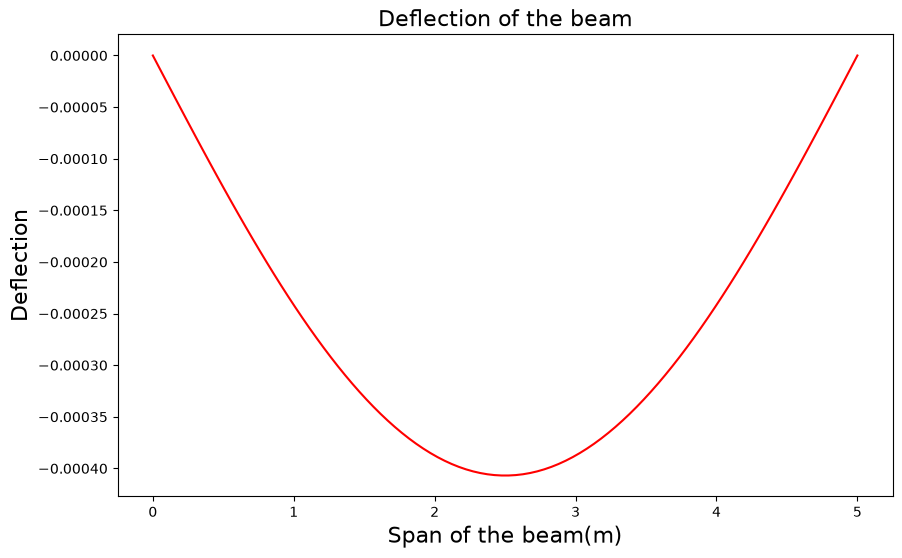

In [4]:
plt.figure(figsize=(10,6))

font = {'color':'black', 'size':'16'}

plt.plot(x_value, deflection, color = 'red')
plt.title('Deflection of the beam', fontdict=font)
plt.xlabel('Span of the beam(m)', fontdict=font)
plt.ylabel('Deflection', fontdict=font)
plt.show()